In [ ]:
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
uploaded = files.upload()
image_path = next(iter(uploaded))

Saving Exercise-3.gif to Exercise-3 (2).gif


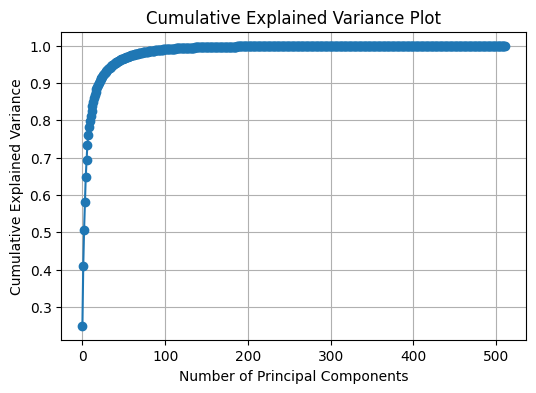

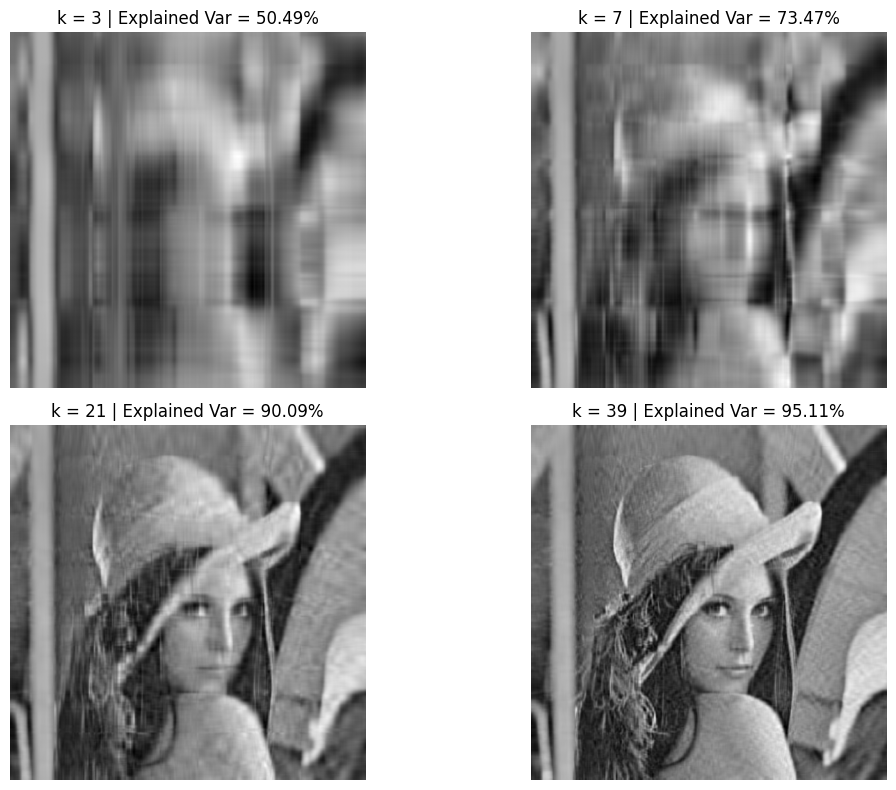

In [ ]:
img = Image.open(image_path)
if img.mode != 'L':
    img = img.convert('L')

X = np.array(img, dtype=np.float64)

mean = np.mean(X, axis=0)
X_centered = X - mean

cov_matrix = np.dot(X_centered.T, X_centered) / (X_centered.shape[0] - 1)

eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(6,4))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid(True)
plt.show()

def pca_reconstruct(X_centered, eigenvectors, mean, k):
    W = eigenvectors[:, :k]
    X_reduced = np.dot(X_centered, W)
    X_reconstructed = np.dot(X_reduced, W.T) + mean
    return X_reconstructed

k_values = [
    np.searchsorted(cumulative_variance, 0.50) + 1,
    np.searchsorted(cumulative_variance, 0.70) + 1,
    np.searchsorted(cumulative_variance, 0.90) + 1,
    np.searchsorted(cumulative_variance, 0.95) + 1
]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):
    X_rec = pca_reconstruct(X_centered, eigenvectors, mean, k)
    plt.subplot(2, 2, i+1)
    plt.imshow(X_rec, cmap='gray')
    plt.title(f"k = {k} | Explained Var = {cumulative_variance[k-1]*100:.2f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()